# Parametric SFH Fitting

Standard parametric SFH (truncated skew-normal, D = 8).

**Two inference methods compared:**
1. `NUTS` — gold-standard HMC, exact posterior
2. `geoVI` (NIFTy) — variational, fast default

Shows: SFH recovery, corner plots, spectrum fits,
convergence diagnostics, and batch timing for 10 galaxies.

In [1]:
import os
import sys
import time
import warnings

os.environ["JAX_PLATFORMS"] = "cpu"

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    _here = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _here = os.getcwd()
proj_root = os.path.abspath(os.path.join(_here, ".."))
os.chdir(proj_root)
sys.path.insert(0, os.path.join(proj_root, "notebooks"))

from tengri import (  # noqa: E402
    Fitter,
    Fixed,
    Model,
    Observation,
    ParamSpec,
    Uniform,
    load_ssp_data,
)
from tengri.models.observation import SpectroscopyConfig  # noqa: E402

from _plot_style import (  # noqa: E402
    COLORS,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

sys.path.insert(0, _here)
from acor import autocorrelation_fft, batch_acor, split_rhat  # noqa: E402

FIGDIR = os.path.join("explore", "figures")
os.makedirs(FIGDIR, exist_ok=True)

## 1. Setup

In [2]:
ssp_data = load_ssp_data(
    "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5",
)
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
obs = Observation(spectroscopy=SpectroscopyConfig(wave_obs=WAVE_OBS))

## 2. Parametric model (D = 8)

In [3]:
spec = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model = Model(spec, ssp_data, observation=obs)
D = len(spec.free_params)
print(f"D = {D} free parameters: {spec.free_params}")

D = 8 free parameters: ['dust_tau_bc', 'dust_tau_diff', 'met_logzsol', 'sfh_tsnorm_log_peak_sfr', 'sfh_tsnorm_peak_lbt_gyr', 'sfh_tsnorm_skew', 'sfh_tsnorm_trunc', 'sfh_tsnorm_width_gyr']


W0331 20:26:46.589321 29966017 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
<local>/Projects/diffsed/src/tengri/core/model.py:503: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


In [4]:
key = jax.random.PRNGKey(42)
true_params = {**spec.sample(key)}
true_params["sfh_tsnorm_log_peak_sfr"] = jnp.array(2.0)  # SFR ~ 100 Msun/yr
true_params["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_skew"] = jnp.array(0.3)
true_params["sfh_tsnorm_trunc"] = jnp.array(2.0)
mock = model.mock_spectrum(true_params, WAVE_OBS, snr=30.0, key=key)

## 3. NUTS (gold-standard HMC)

Exact posterior via Hamiltonian Monte Carlo. Best for low-D parametric
models where you want the ground-truth posterior.

In [5]:
fitter = Fitter(model, mock.flux_obs, mock.noise)

t0 = time.perf_counter()
fitter.compile(verbose=False)
t_compile = time.perf_counter() - t0

t0 = time.perf_counter()
result_map = fitter.run("map", n_steps=500, verbose=False)
t_map = time.perf_counter() - t0

t0 = time.perf_counter()
result_nuts = fitter.run(
    "nuts",
    init_from=result_map,
    n_warmup=500,
    n_samples=500,
    target_accept_rate=0.85,
    verbose=False,
)
t_nuts = time.perf_counter() - t0

print(f"Compile: {t_compile:.1f}s  |  MAP: {t_map:.1f}s  |  "
      f"NUTS: {t_nuts:.1f}s")

assuming the specified inverse covariance is diagonal
assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`
./.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)
W0331 20:26:50.023498 29965880 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0331 20:26:52.194644 29965880 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0331 20:26:55.066261 29965880 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0331 20:27:04.219187 29965880 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0331 20:27:08.687965 29965880 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0331 20:27:10.

Compile: 22.5s  |  MAP: 0.7s  |  NUTS: 55.9s


### 3a. NUTS convergence

In [6]:
print("tengri check_convergence (NUTS):")
result_nuts.check_convergence(verbose=True)

tengri check_convergence (NUTS):
Parameter               τ (std)  τ (abs)  τ (max)      ESS  Conv?
-----------------------------------------------------------------
dust_tau_bc                 2.0      2.2      2.2      230     OK
dust_tau_diff               2.0      2.7      2.7      187     OK
met_logzsol                 2.1      2.7      2.7      183     OK
sfh_tsnorm_log_peak_sfr      2.1      2.8      2.8      181     OK
sfh_tsnorm_peak_lbt_gyr      2.1      3.0      3.0      167     OK


{'all_converged': True,
 'params': {'dust_tau_bc': {'tau_standard': 1.9841982637541615,
   'tau_absolute': 2.1746432585613102,
   'tau_max': 2.1746432585613102,
   'ess': 229.9227691859618,
   'chain_converged': True},
  'dust_tau_diff': {'tau_standard': 1.9780651016270139,
   'tau_absolute': 2.677365823112404,
   'tau_max': 2.677365823112404,
   'ess': 186.75072180414864,
   'chain_converged': True},
  'met_logzsol': {'tau_standard': 2.1306778026911988,
   'tau_absolute': 2.7375689029085675,
   'tau_max': 2.7375689029085675,
   'ess': 182.64380467968064,
   'chain_converged': True},
  'sfh_tsnorm_log_peak_sfr': {'tau_standard': 2.104156578695312,
   'tau_absolute': 2.765286149673321,
   'tau_max': 2.765286149673321,
   'ess': 180.81311406382585,
   'chain_converged': True},
  'sfh_tsnorm_peak_lbt_gyr': {'tau_standard': 2.0634095201109113,
   'tau_absolute': 2.9965761751671054,
   'tau_max': 2.9965761751671054,
   'ess': 166.85709649016925,
   'chain_converged': True}},
 'warnings': []

In [7]:
# External FFT cross-check + split R-hat
samples_nuts = result_nuts.samples
scalar = {
    k: np.asarray(v) for k, v in samples_nuts.items()
    if np.asarray(v).ndim == 1 and np.var(np.asarray(v)) > 1e-30
}
names = sorted(scalar.keys())
arr2d = np.column_stack([scalar[k] for k in names])
taus, converged = batch_acor(arr2d, c=5.0)
rhats = split_rhat(arr2d)
n_samp = arr2d.shape[0]

print(f"\n{'Parameter':<30s} {'τ(FFT)':>7s} {'ESS':>6s} "
      f"{'R-hat':>7s} {'OK?':>5s}")
print("-" * 57)
for i, name in enumerate(names):
    ess = n_samp / (2.0 * taus[i]) if taus[i] > 0 else n_samp
    ok = converged[i] and rhats[i] < 1.05
    print(f"{name:<30s} {taus[i]:>7.1f} {ess:>6.0f} "
          f"{rhats[i]:>7.4f} {'OK' if ok else 'WARN':>5s}")


Parameter                       τ(FFT)    ESS   R-hat   OK?
---------------------------------------------------------
dust_tau_bc                        0.8    331  0.9986    OK
dust_tau_diff                      0.5    518  0.9991    OK
met_logzsol                        0.8    322  0.9980    OK
sfh_tsnorm_log_peak_sfr            0.5    501  0.9987    OK
sfh_tsnorm_peak_lbt_gyr            0.5    483  0.9983    OK


### 3b. NUTS SFH recovery

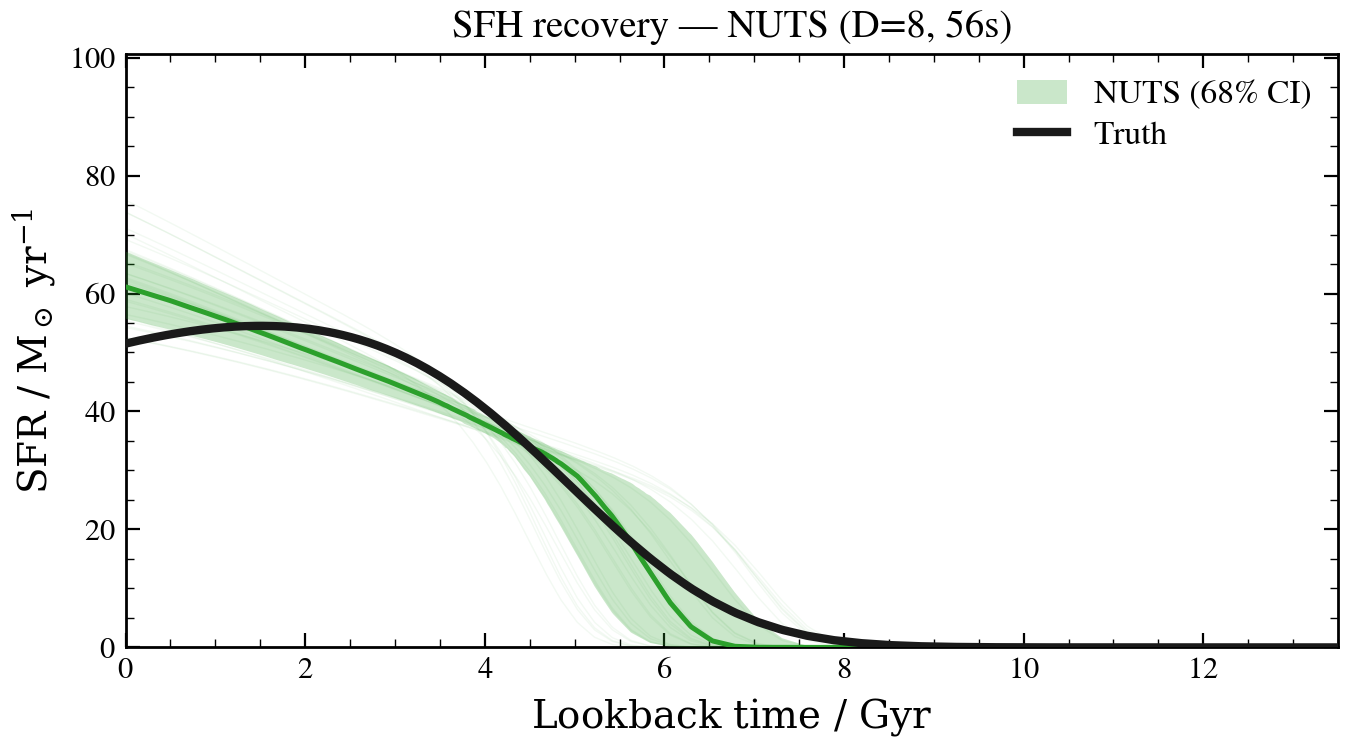

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_sfh(model, result_nuts, true_params=true_params, ax=ax,
         method="NUTS", label="NUTS")
ax.set_title(f"SFH recovery — NUTS (D={D}, {t_nuts:.0f}s)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_sfh_nuts.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### 3c. NUTS corner plot

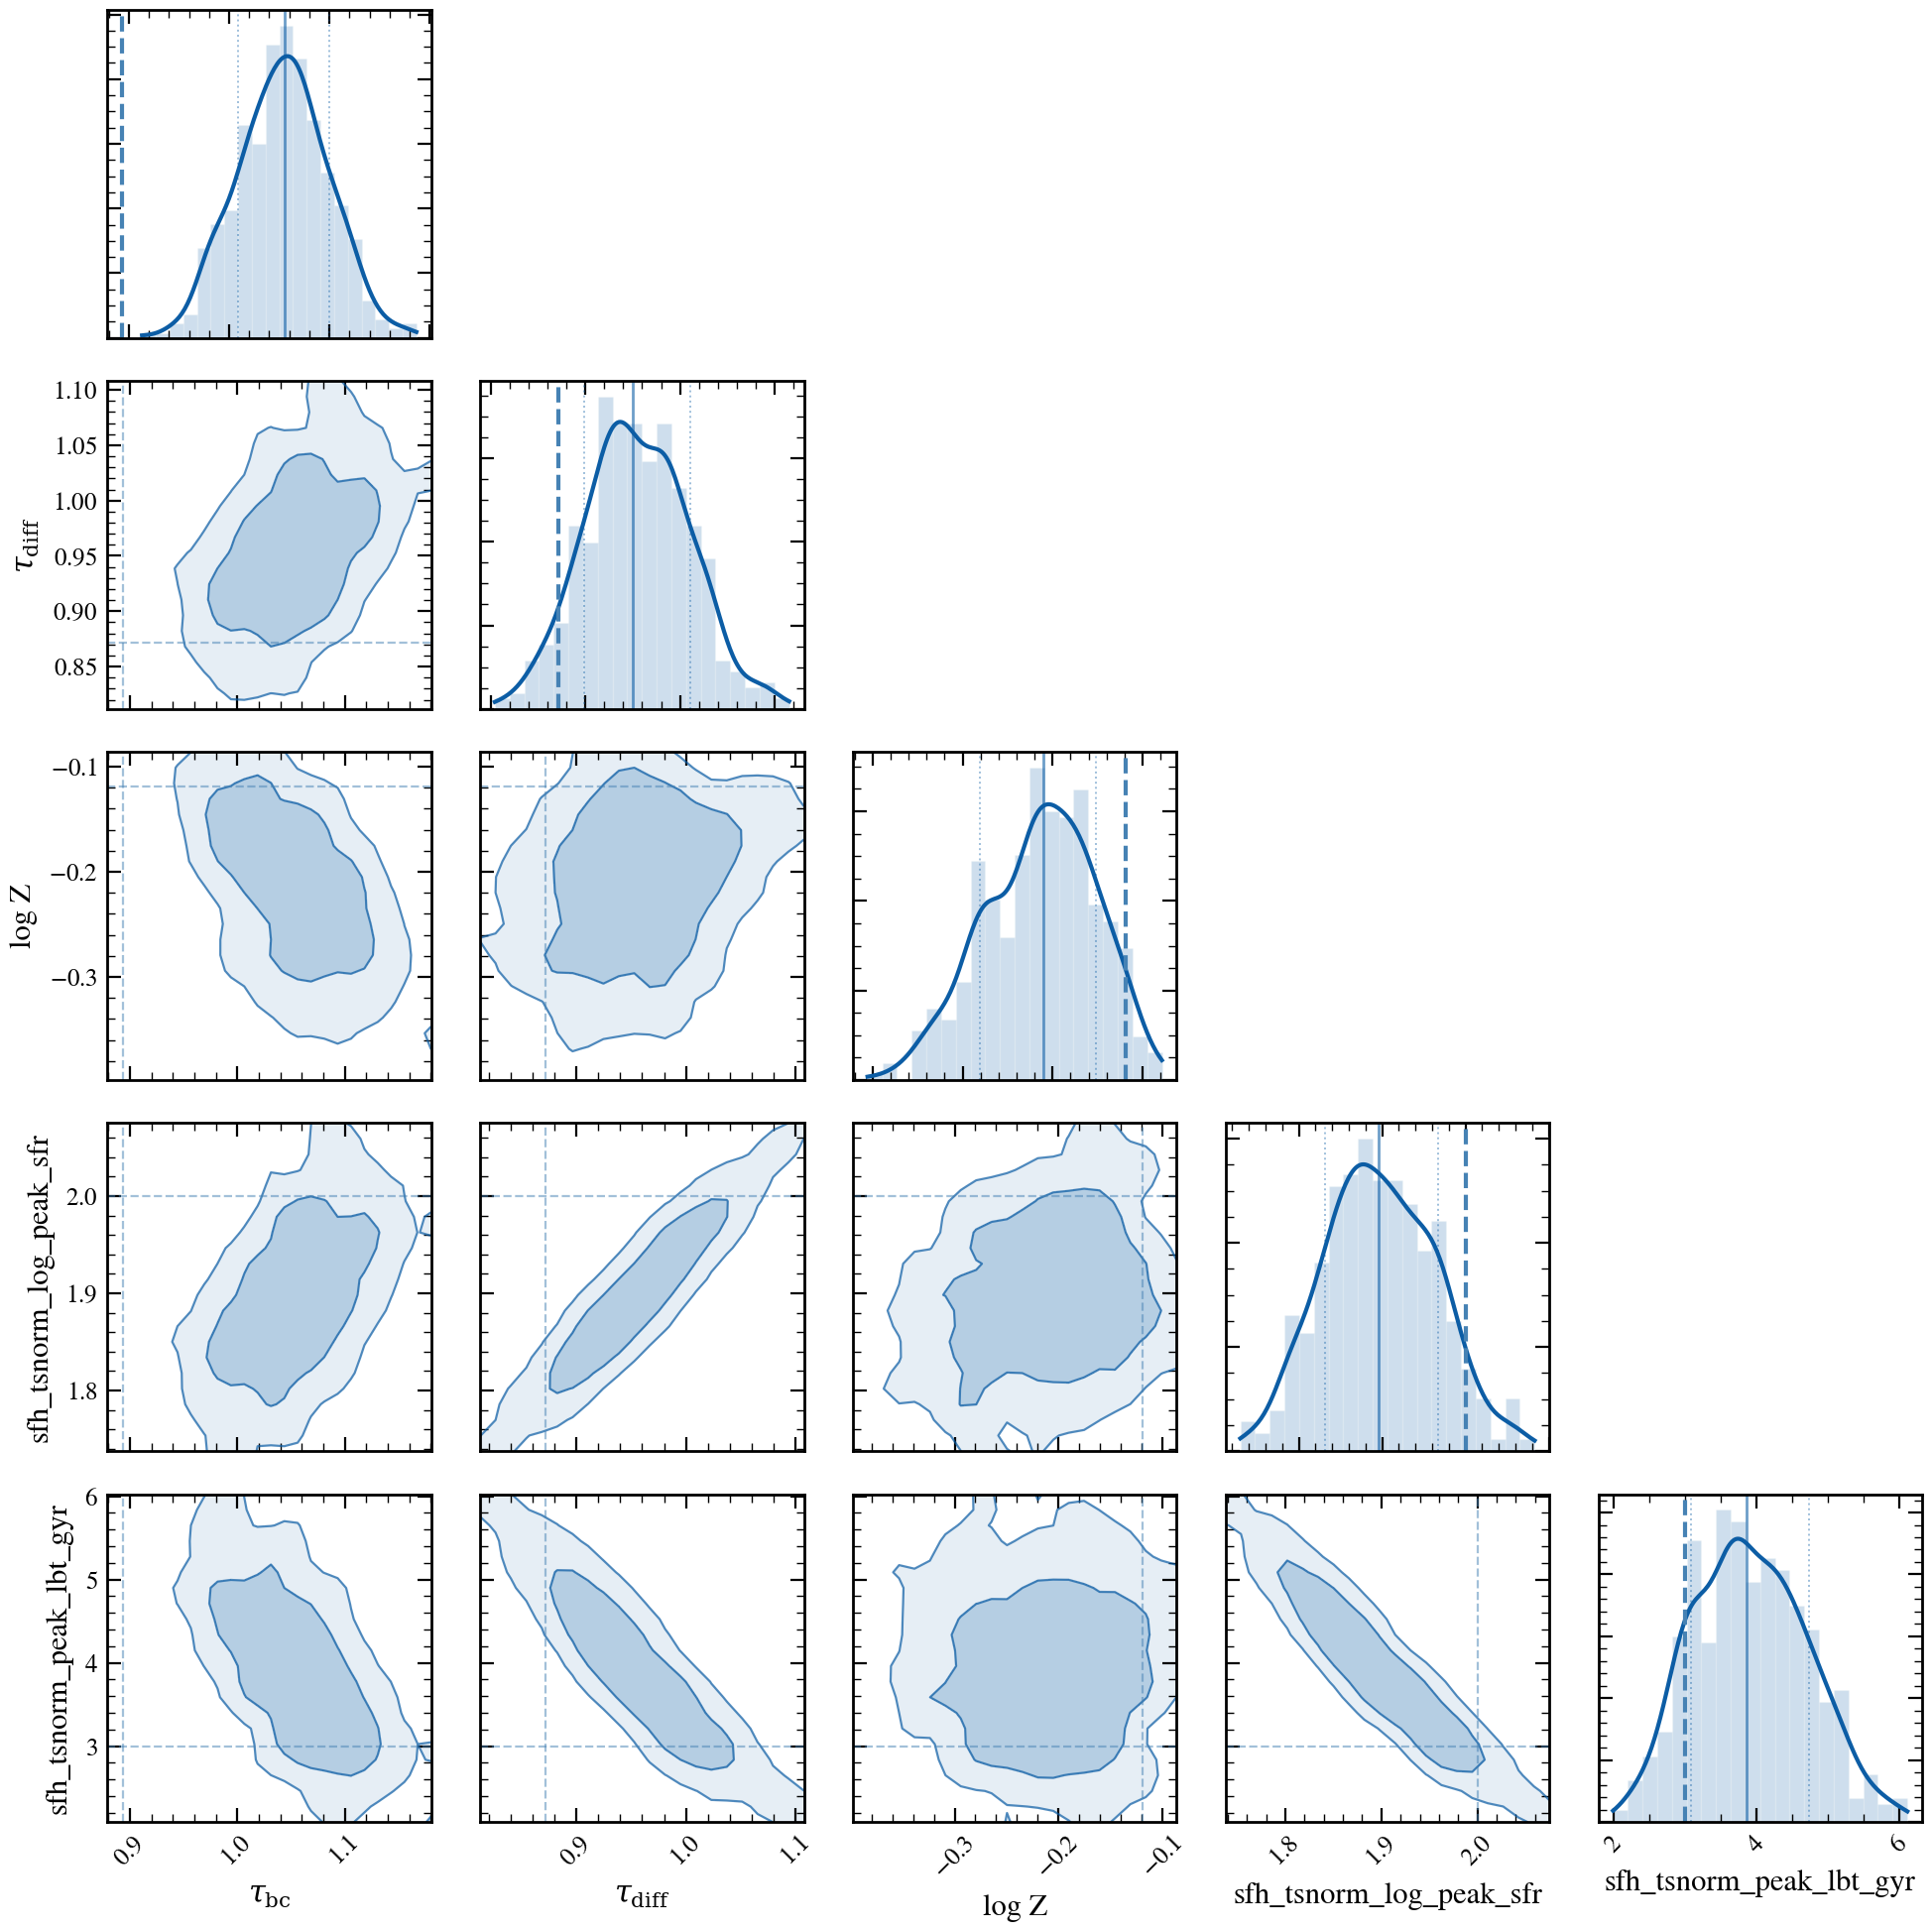

In [9]:
fig = safe_corner(result_nuts, truths=true_params)
if fig is not None:
    fig.savefig(os.path.join(FIGDIR, "01_corner_nuts.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

## 4. geoVI — NIFTy fast path (default)

Geometric variational inference. Much faster than NUTS, produces
approximate posteriors. Default method for production fitting.

In [10]:
t0 = time.perf_counter()
result_geovi = fitter.run(
    "geovi", n_iterations=10, n_posterior_samples=500, verbose=True,
)
t_geovi = time.perf_counter() - t0
print(f"\ngeoVI (NIFTy): {t_geovi:.1f}s")

  init_from='auto' → 'random' (n_seeds=5; random starts are better for multi-seed exploration)
  parallel_seeds=False (auto: cpu backend; sequential is faster on CPU due to early stopping)
geoVI (JIT): 8 params, 200 data points, 10 iterations, 3 samples/iter, 5 seeds


W0331 20:28:29.745505 29965880 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  Seed 1/5: H=106.1, 10 iters
  Seed 2/5: H=103.9, 10 iters
  Seed 3/5: H=102.5, 10 iters
  Seed 4/5: H=105.8, 9 iters
  Seed 5/5: H=102.4, 8 iters
  Drawing 500 nonlinear posterior samples (JIT geoVI)...


W0331 20:28:42.649264 29965880 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  EVI (JIT) complete in 36.0s, 8/10 iterations, 500 posterior samples

geoVI (NIFTy): 36.7s


### 4a. geoVI results

In [11]:
result_geovi.summary_table()

'Posterior  method: EVI (JIT)  samples: 500  wall_time: 36.0s\n──────────────────────────────────────────────────────────────────\n  Parameter                       Median       16%       84%     ESS\n  ────────────────────────────────────────────────────────────────\n  dust_Rv                         3.1000    3.1000    3.1000       —\n  dust_bump_strength              0.0000    0.0000    0.0000       —\n  dust_delta                      0.0000    0.0000    0.0000       —\n  dust_f_obscuration              0.0000    0.0000    0.0000       —\n  dust_slope                     -0.7000   -0.7000   -0.7000       —\n  dust_tau_bc                     0.9010    0.8388    0.9626       —\n  dust_tau_diff                   0.8051    0.7485    0.8630       —\n  met_alpha_fe                    0.0000    0.0000    0.0000       —\n  met_logzsol                    -0.2701   -0.3119   -0.1902       —\n  noise_dof                       0.0000    0.0000    0.0000       —\n  noise_frac_cal               

### 4b. geoVI SFH recovery

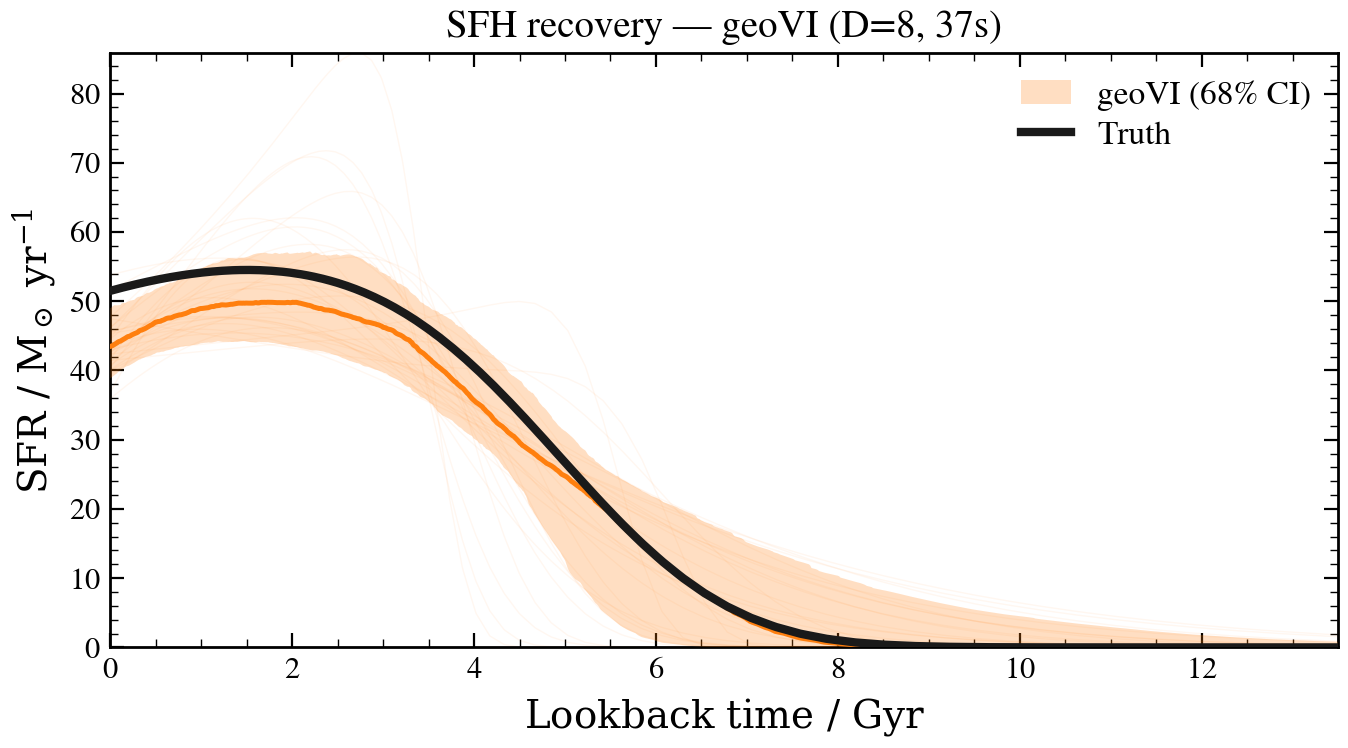

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_sfh(model, result_geovi, true_params=true_params, ax=ax,
         method="geoVI", label="geoVI")
ax.set_title(f"SFH recovery — geoVI (D={D}, {t_geovi:.0f}s)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_sfh_geovi.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### 4c. geoVI corner plot

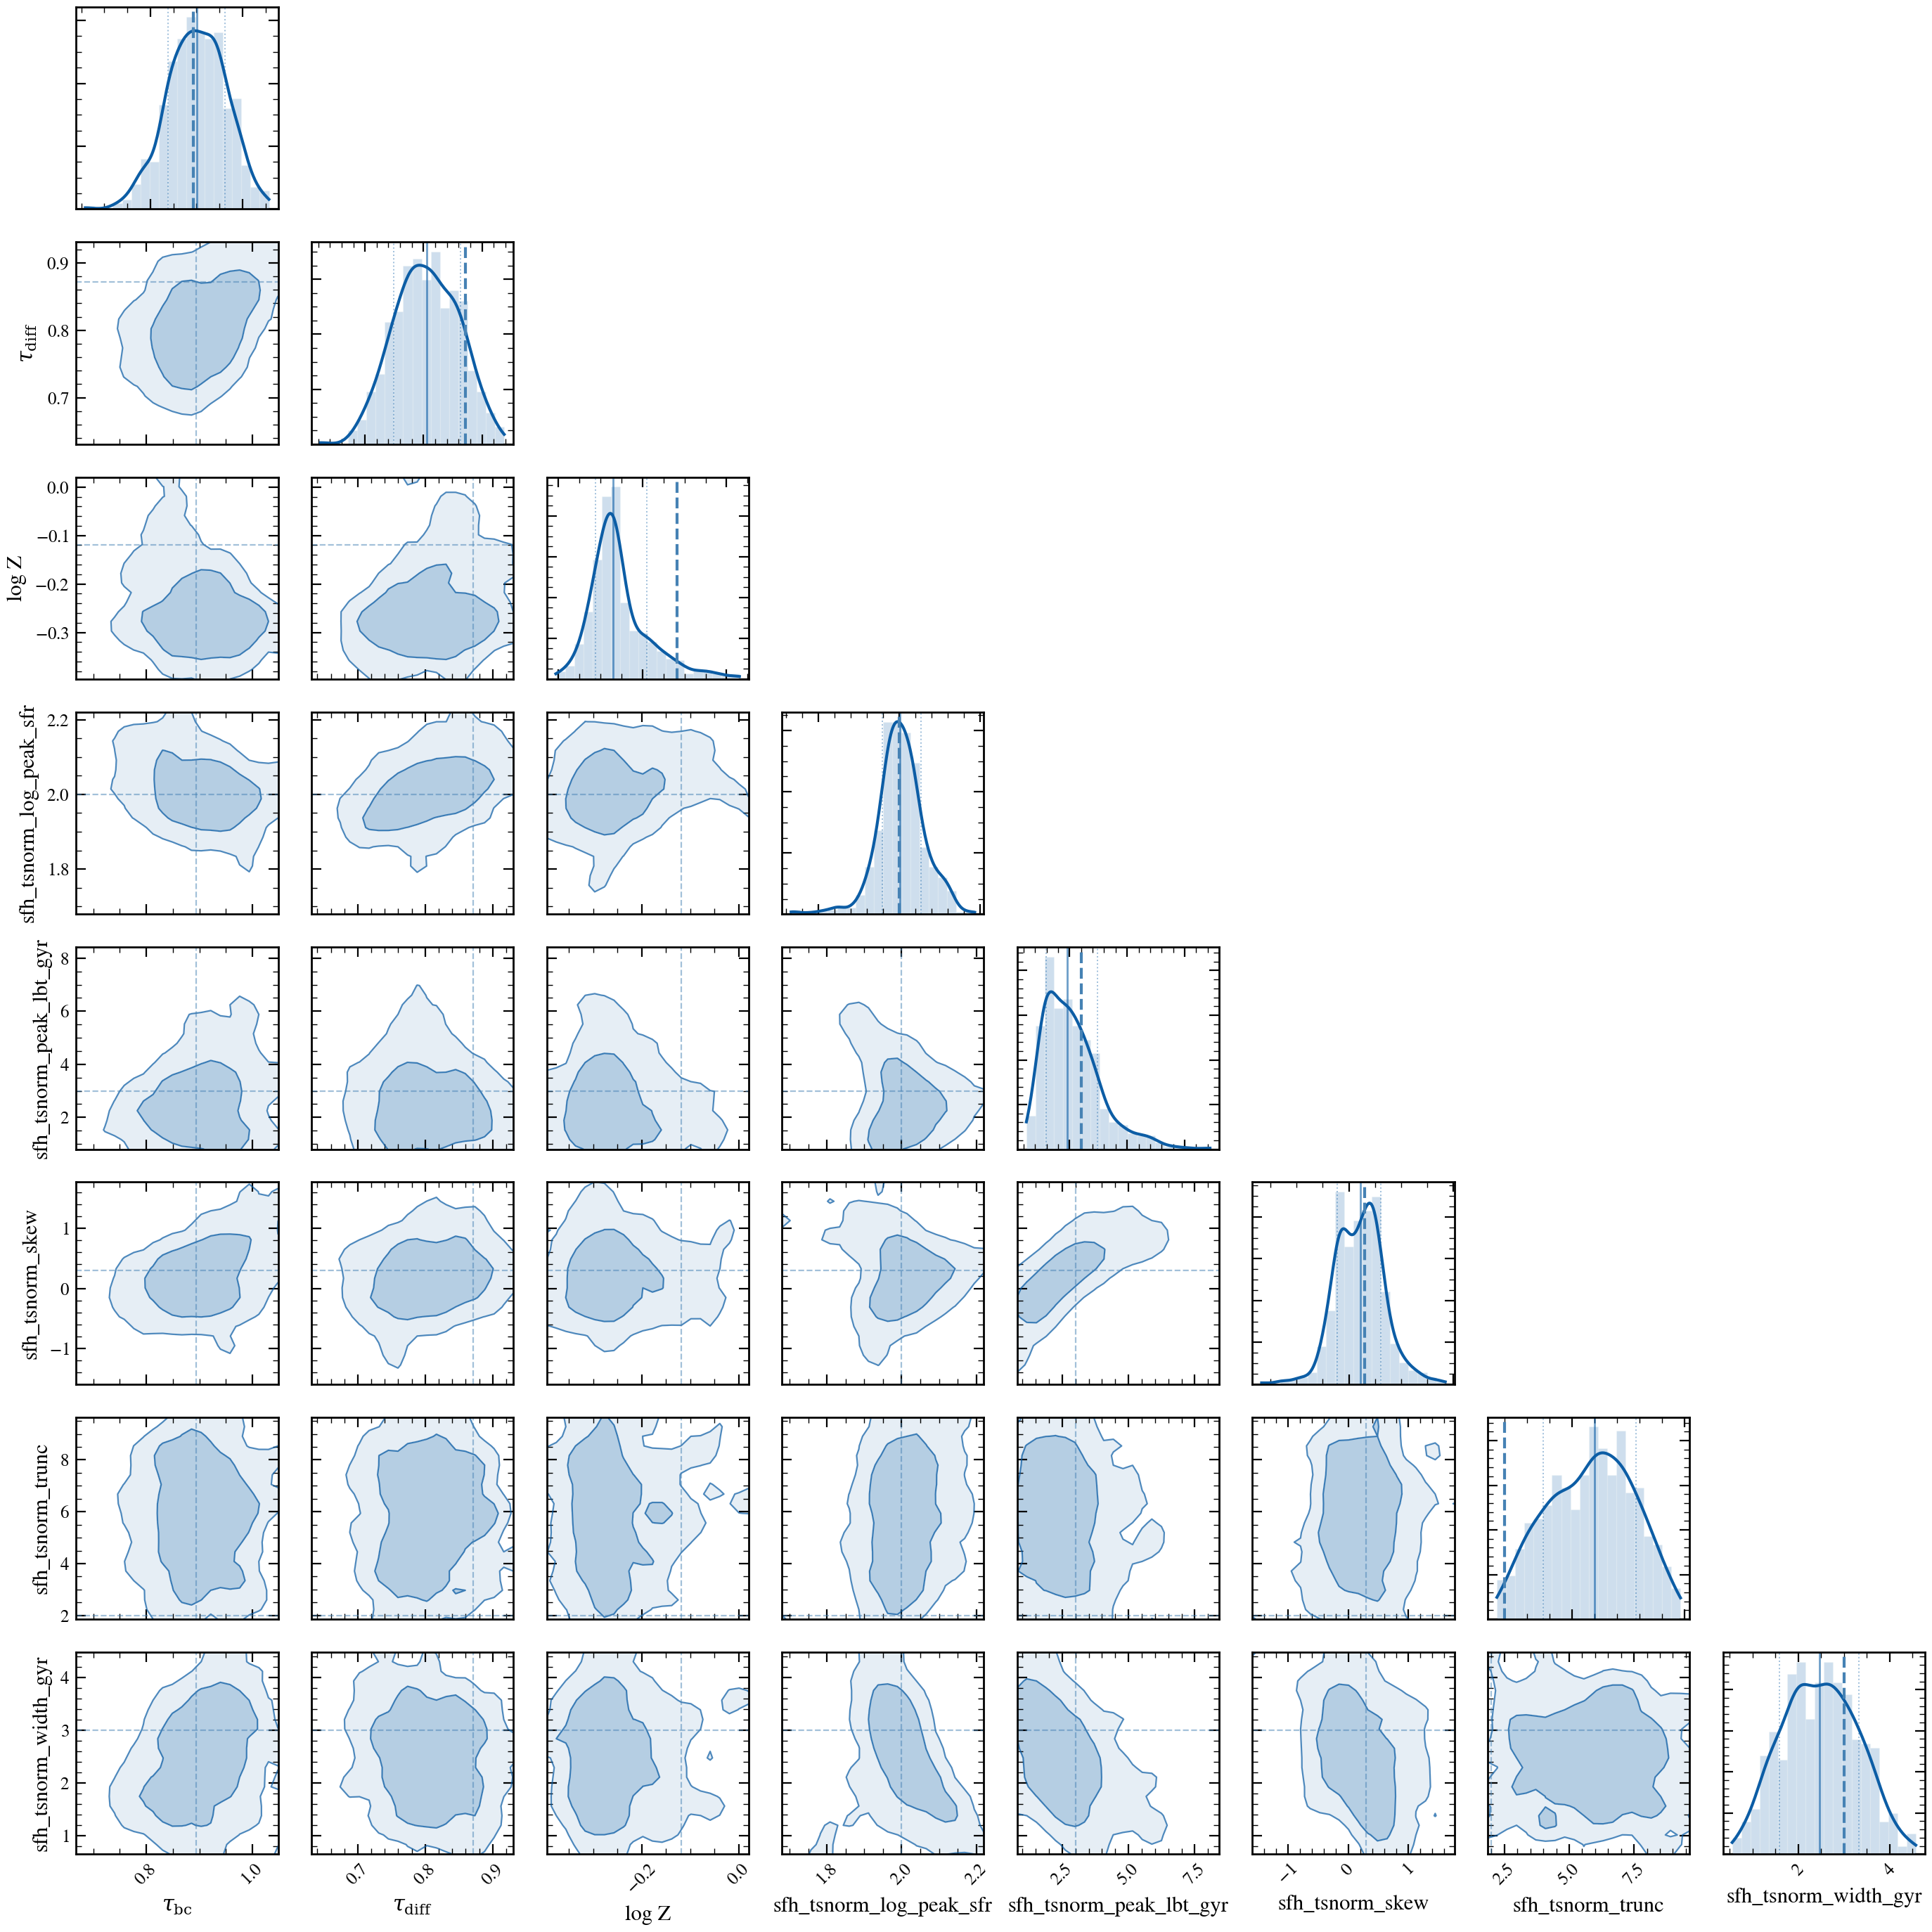

In [13]:
fig = safe_corner(result_geovi, truths=true_params)
if fig is not None:
    fig.savefig(os.path.join(FIGDIR, "01_corner_geovi.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

## 5. Comparison — NUTS vs geoVI

### 5a. SFH side-by-side

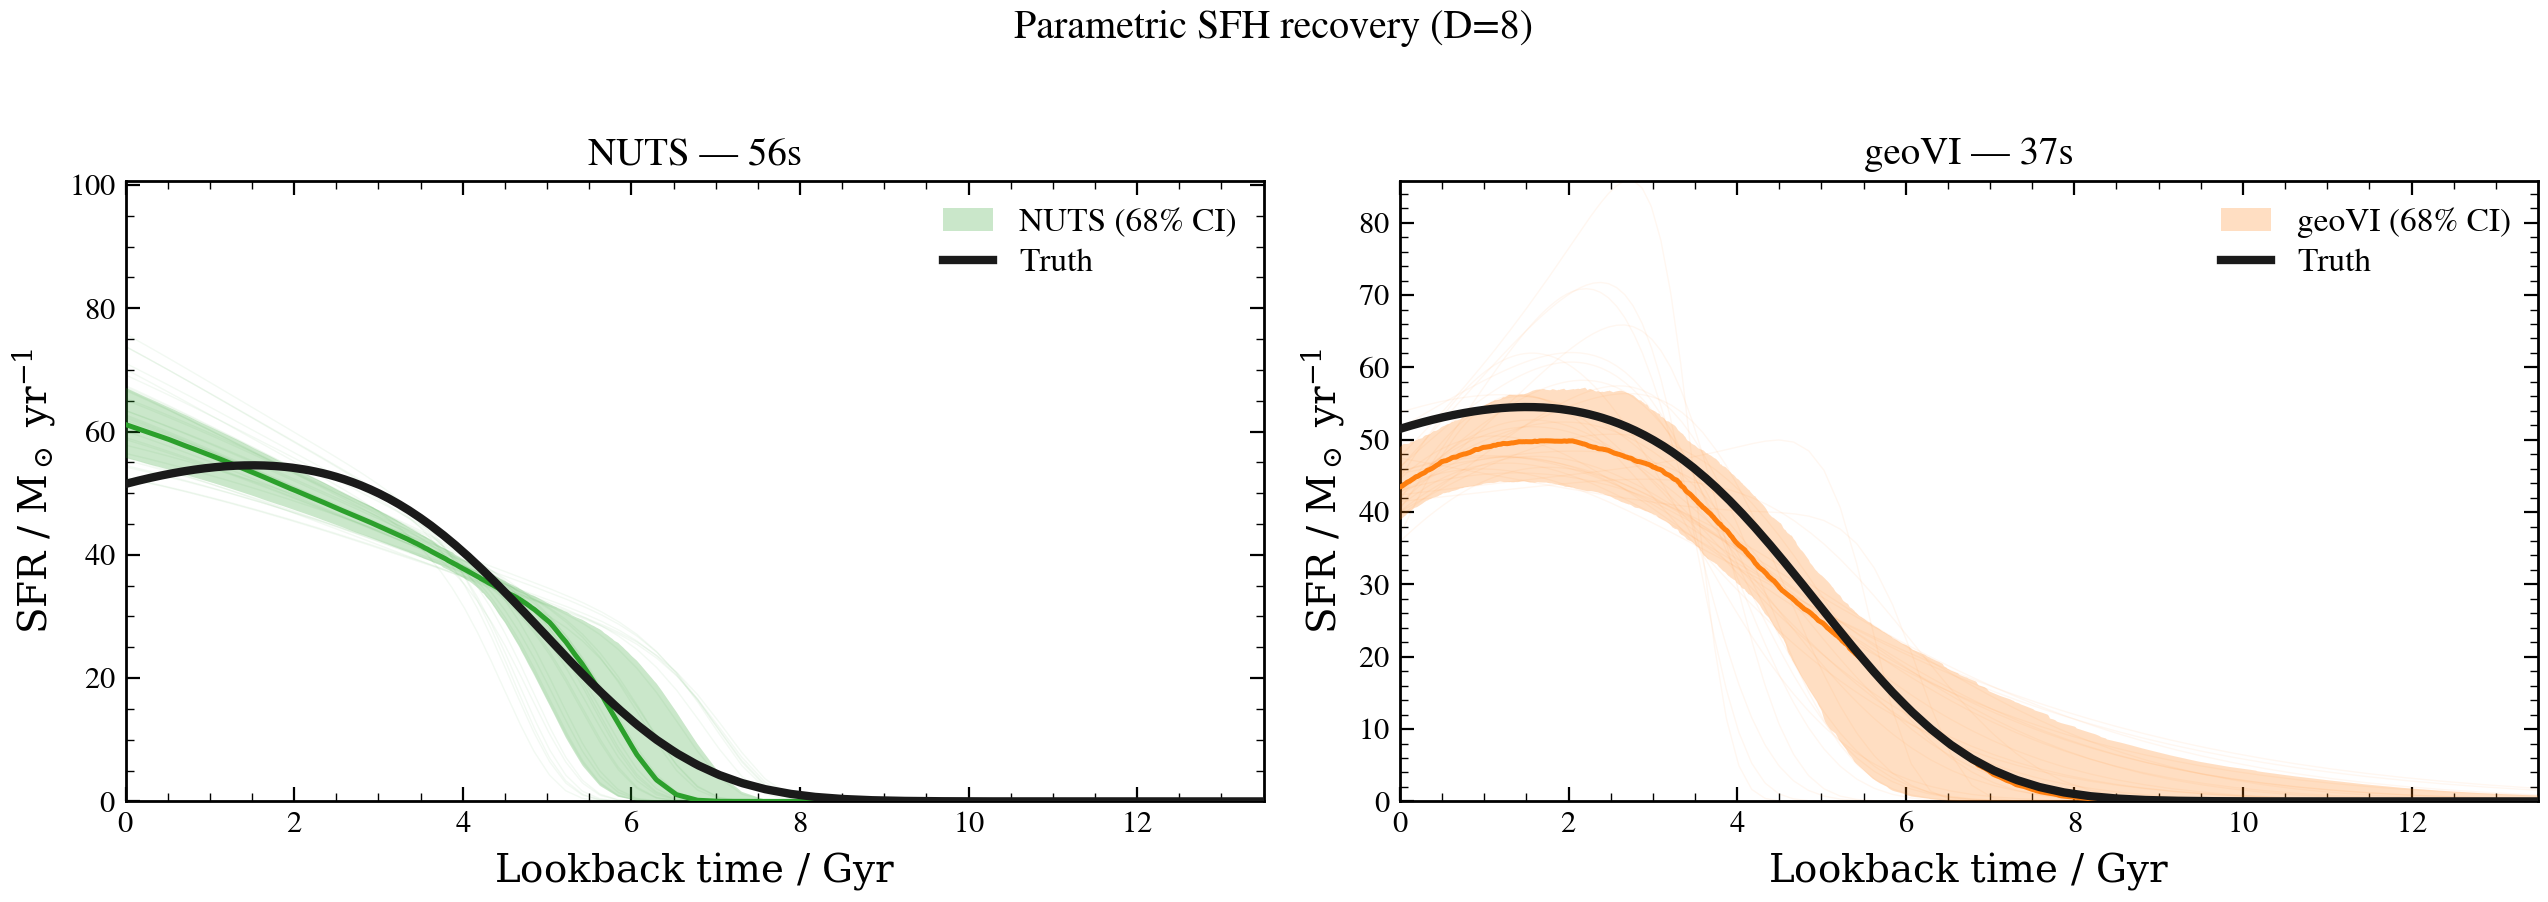

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
plot_sfh(model, result_nuts, true_params=true_params, ax=ax1,
         method="NUTS", label="NUTS")
ax1.set_title(f"NUTS — {t_nuts:.0f}s")
plot_sfh(model, result_geovi, true_params=true_params, ax=ax2,
         method="geoVI", label="geoVI")
ax2.set_title(f"geoVI — {t_geovi:.0f}s")
fig.suptitle(f"Parametric SFH recovery (D={D})", y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_sfh_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### 5b. Corner overlay

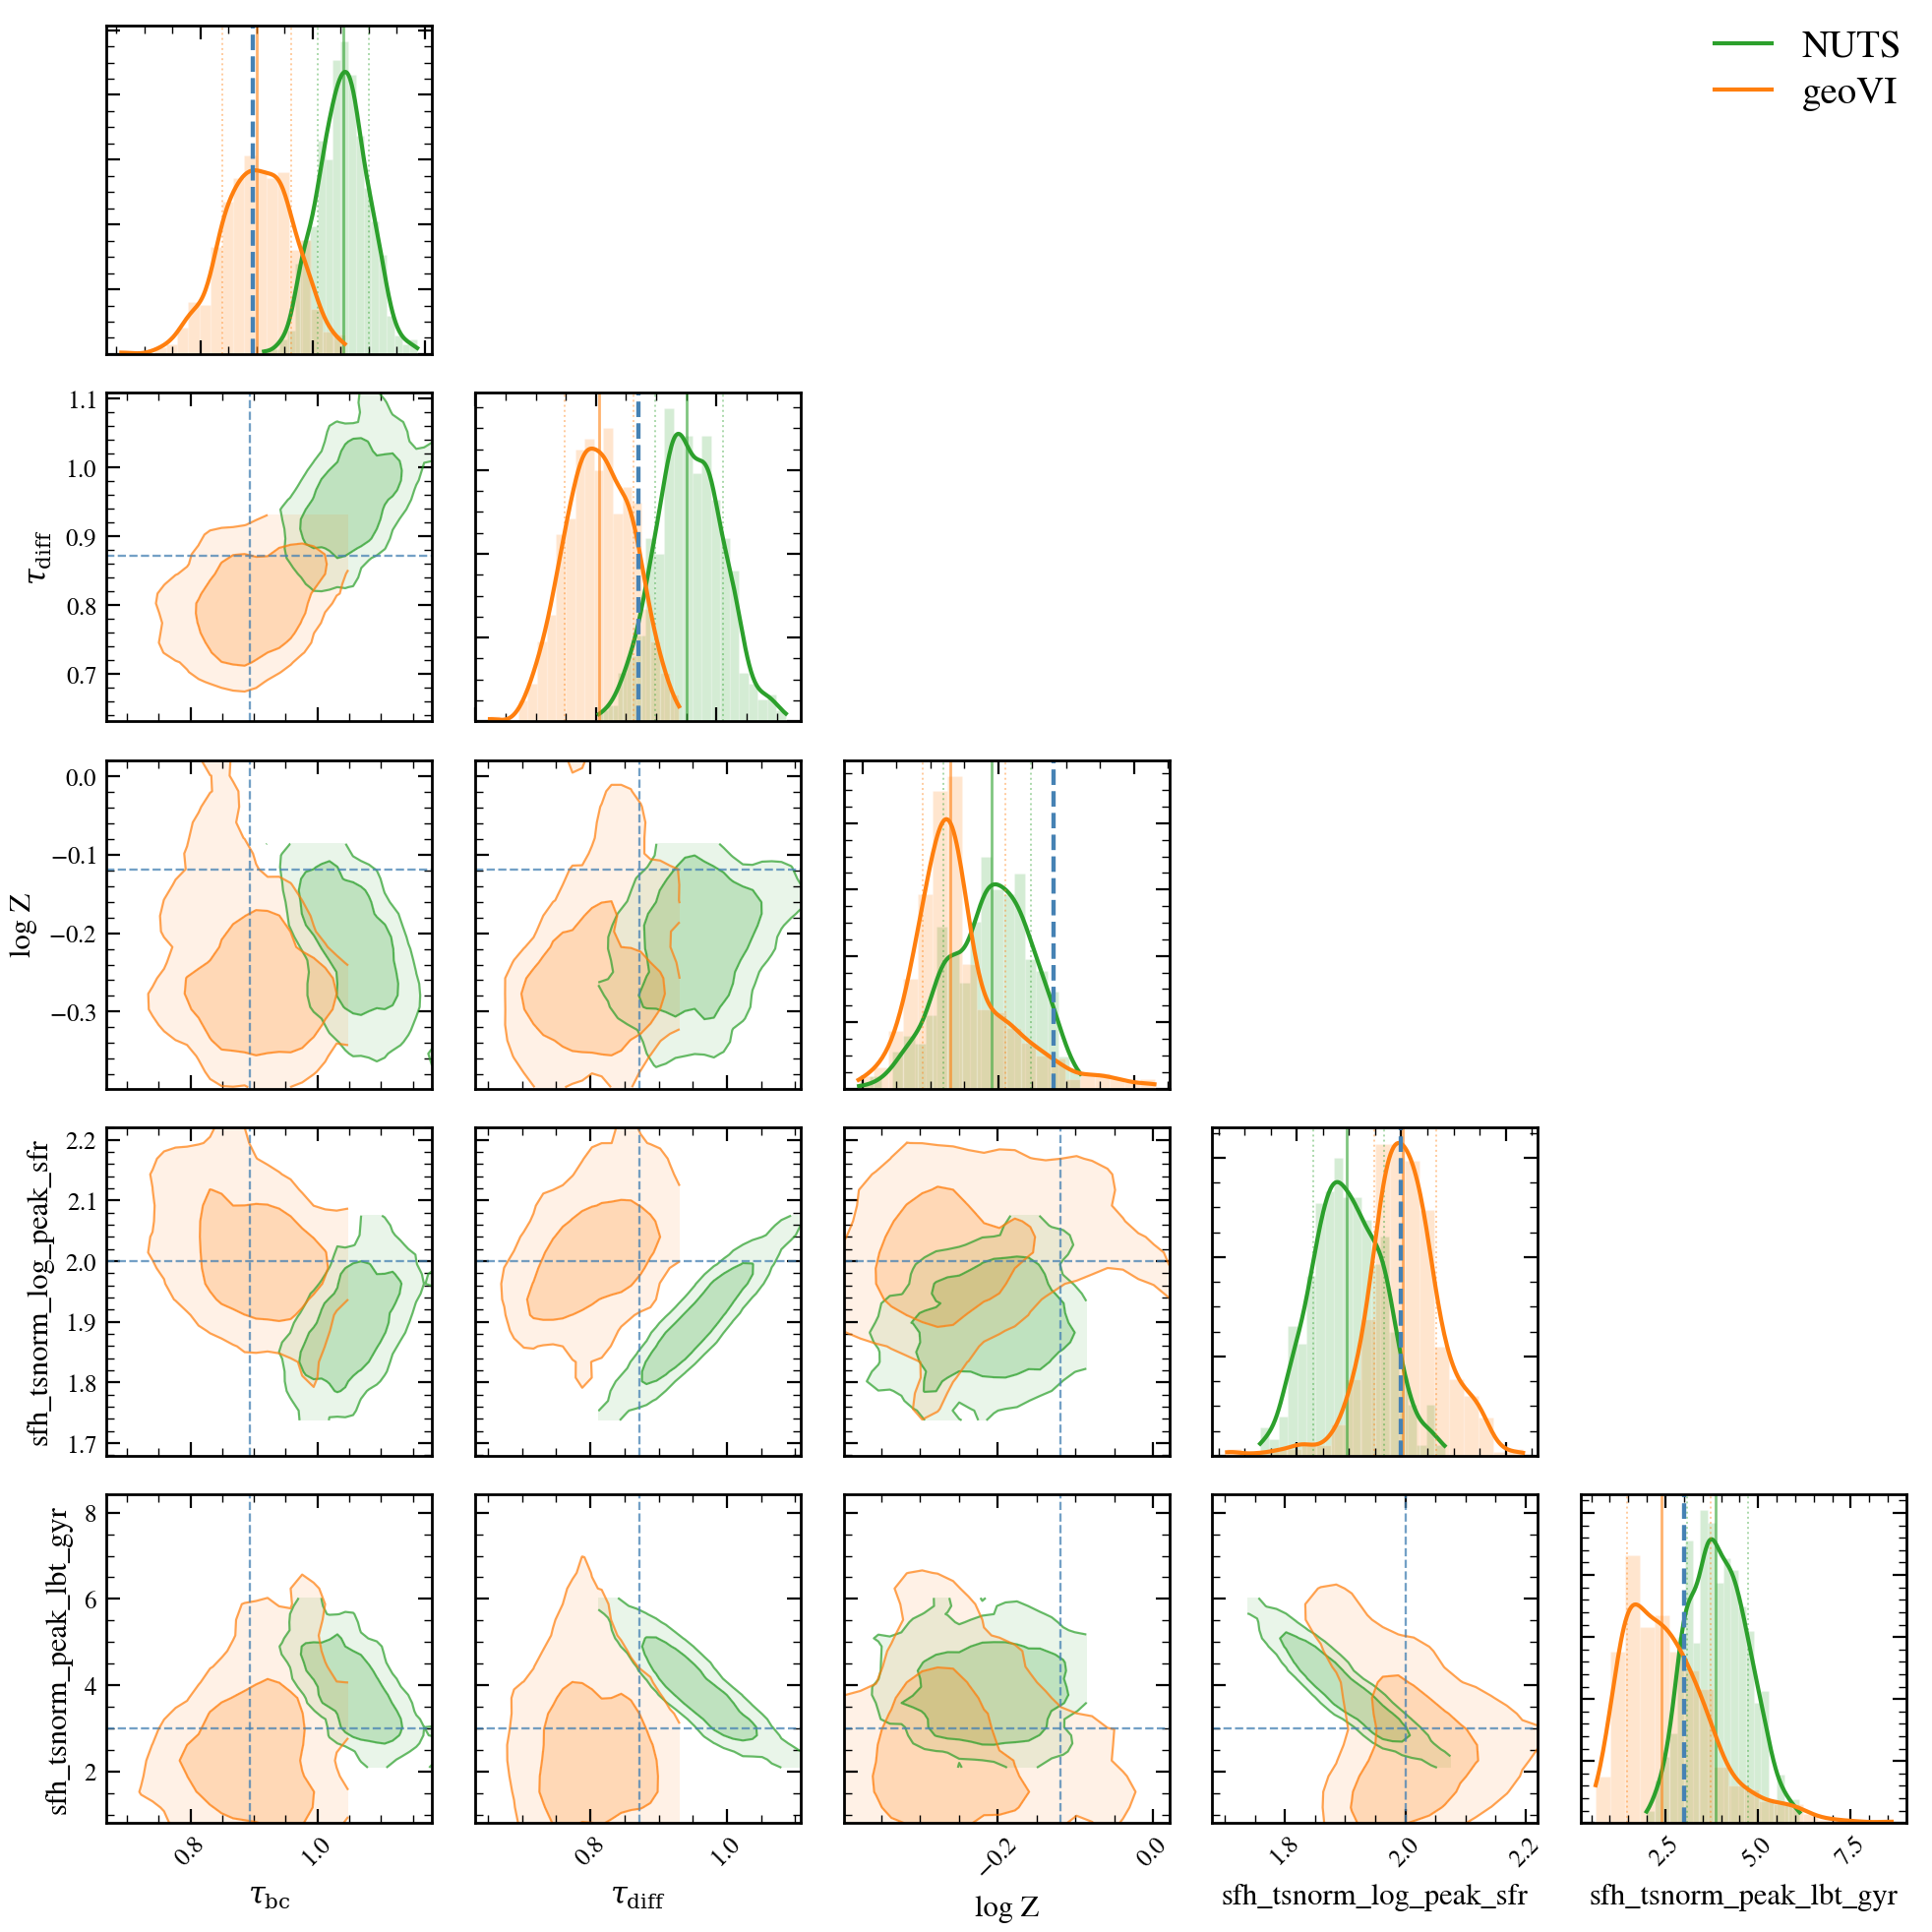

In [15]:
fig = plot_corner_comparison(
    [result_nuts, result_geovi],
    labels=["NUTS", "geoVI"],
    colors=[COLORS["nuts"], COLORS["geovi"]],
    truths=true_params,
)
if fig is not None:
    fig.savefig(os.path.join(FIGDIR, "01_corner_comparison.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

### 5c. Spectrum fits

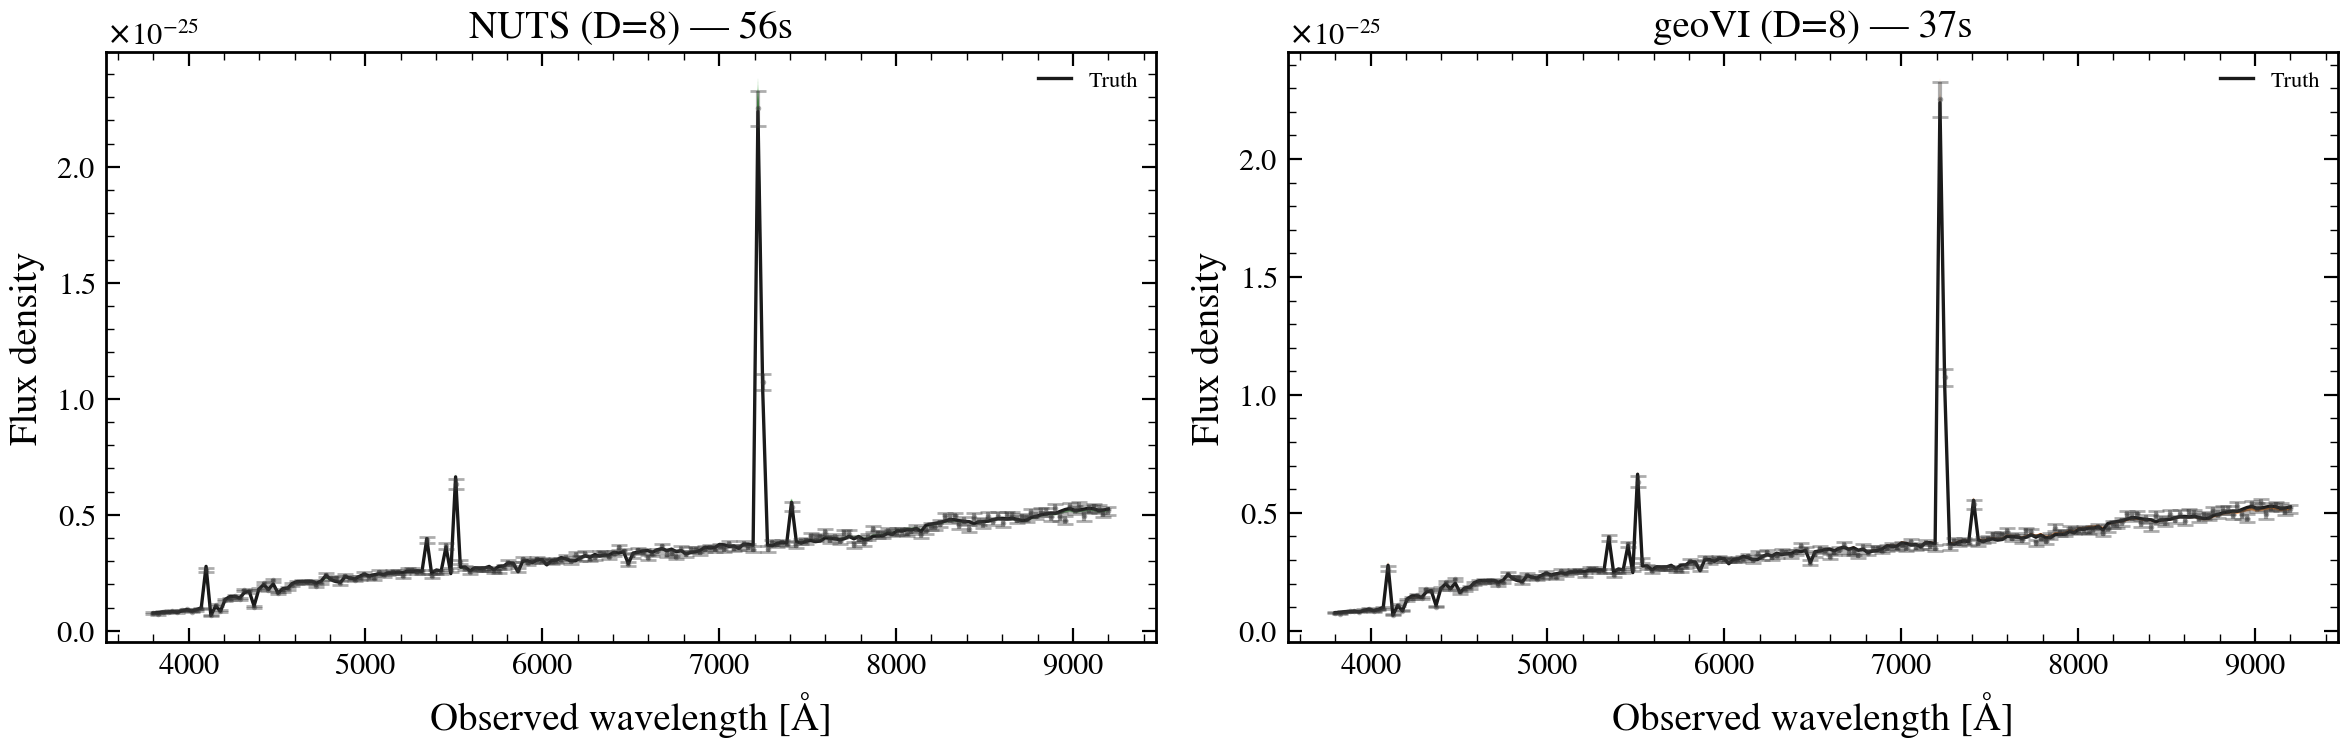

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, result, label, color, t in [
    (axes[0], result_nuts, "NUTS", COLORS["nuts"], t_nuts),
    (axes[1], result_geovi, "geoVI", COLORS["geovi"], t_geovi),
]:
    s = result.samples
    nd = min(50, len(list(s.values())[0]))
    for j in range(nd):
        draw = {k: v[j] for k, v in s.items()}
        pred = model.predict_spectrum(draw, WAVE_OBS)
        ax.plot(np.array(WAVE_OBS), np.array(pred),
                color=color, alpha=0.06, lw=0.5)
    ax.errorbar(np.array(WAVE_OBS), np.array(mock.flux_obs),
                yerr=np.array(mock.noise), fmt=".", ms=2,
                color=COLORS["data"], alpha=0.4, zorder=5)
    ax.plot(np.array(WAVE_OBS), np.array(mock.flux_true),
            color=COLORS["truth"], lw=1.2, label="Truth")
    ax.set_xlabel("Observed wavelength [Å]")
    ax.set_ylabel("Flux density")
    ax.set_title(f"{label} (D={D}) — {t:.0f}s")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_spectrum_fit.png"), dpi=150)
plt.show()

## 6. Batch: 10 galaxies

In [17]:
N_BATCH = 10
batch_keys = jax.random.split(jax.random.PRNGKey(999), N_BATCH)

times_nuts = []
times_geovi = []

for i, bk in enumerate(batch_keys):
    true_i = spec.sample(bk)
    mock_i = model.mock_spectrum(true_i, WAVE_OBS, snr=30.0, key=bk)
    f_i = Fitter(model, mock_i.flux_obs, mock_i.noise)

    # NUTS
    t0 = time.perf_counter()
    r_map = f_i.run("map", n_steps=500, verbose=False)
    r_nuts = f_i.run("nuts", init_from=r_map, n_warmup=500,
                      n_samples=500, target_accept_rate=0.85,
                      verbose=False)
    dt_nuts = time.perf_counter() - t0
    times_nuts.append(dt_nuts)

    # geoVI
    t0 = time.perf_counter()
    r_geovi = f_i.run("geovi", n_iterations=10,
                       n_posterior_samples=500, verbose=False)
    dt_geovi = time.perf_counter() - t0
    times_geovi.append(dt_geovi)

    print(f"  Galaxy {i+1:>2d}: NUTS={dt_nuts:.1f}s  "
          f"geoVI={dt_geovi:.1f}s")

<local>/Projects/diffsed/src/tengri/inference/fitter.py:2397: UserWarning: Seeds disagree: H = 168.3 ± 117.7 (CV=70%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(


  Galaxy  1: NUTS=58.7s  geoVI=6.6s
  Galaxy  2: NUTS=50.9s  geoVI=8.7s


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2397: UserWarning: Seeds disagree: H = 153.0 ± 24.9 (CV=16%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(


  Galaxy  3: NUTS=45.4s  geoVI=9.5s
  Galaxy  4: NUTS=53.1s  geoVI=7.1s
  Galaxy  5: NUTS=40.3s  geoVI=6.2s
  Galaxy  6: NUTS=55.7s  geoVI=6.1s
  Galaxy  7: NUTS=56.5s  geoVI=6.3s
  Galaxy  8: NUTS=50.4s  geoVI=7.2s


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2397: UserWarning: Seeds disagree: H = 732.7 ± 1077.7 (CV=147%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(
<local>/Projects/diffsed/src/tengri/inference/fitter.py:2397: UserWarning: Parameters near bounds: sfh_tsnorm_log_peak_sfr. Consider widening the prior.
  return self._run_native_vi(


  Galaxy  9: NUTS=49.5s  geoVI=7.5s
  Galaxy 10: NUTS=51.0s  geoVI=5.9s


In [18]:
print("\n" + "=" * 55)
print(f"{'Method':<20s} {'Mean/gal':>10s} {'Total':>10s}")
print("-" * 55)
print(f"{'NUTS':<20s} "
      f"{np.mean(times_nuts):>9.1f}s "
      f"{np.sum(times_nuts):>9.0f}s")
print(f"{'geoVI (NIFTy)':<20s} "
      f"{np.mean(times_geovi):>9.1f}s "
      f"{np.sum(times_geovi):>9.0f}s")
print("=" * 55)


Method                 Mean/gal      Total
-------------------------------------------------------
NUTS                      51.1s       511s
geoVI (NIFTy)              7.1s        71s


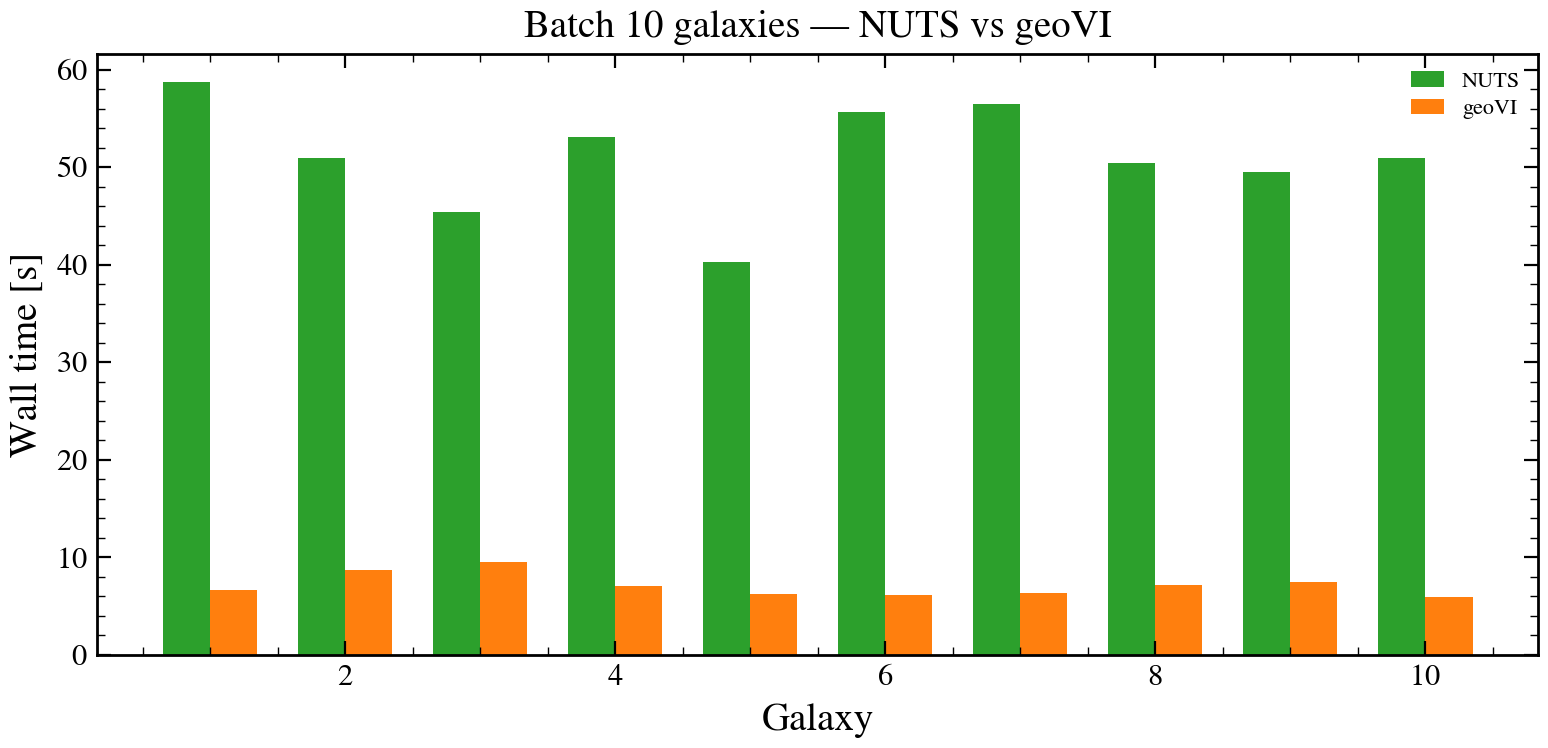

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, N_BATCH + 1)
w = 0.35
ax.bar(x - w / 2, times_nuts, w, label="NUTS", color=COLORS["nuts"])
ax.bar(x + w / 2, times_geovi, w, label="geoVI",
       color=COLORS["geovi"])
ax.set_xlabel("Galaxy")
ax.set_ylabel("Wall time [s]")
ax.set_title(f"Batch {N_BATCH} galaxies — NUTS vs geoVI")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "01_batch_comparison.png"), dpi=150)
plt.show()

## 7. Timing summary

In [20]:
print("=" * 50)
print(f"{'Scenario':<30s} {'Time':>10s}")
print("-" * 50)
print(f"{'NUTS (single galaxy)':<30s} {t_nuts:>9.1f}s")
print(f"{'geoVI (single galaxy)':<30s} {t_geovi:>9.1f}s")
print(f"{'NUTS batch (mean/gal)':<30s} "
      f"{np.mean(times_nuts):>9.1f}s")
print(f"{'geoVI batch (mean/gal)':<30s} "
      f"{np.mean(times_geovi):>9.1f}s")
print(f"{'Compile (one-time)':<30s} {t_compile:>9.1f}s")
print("=" * 50)

Scenario                             Time
--------------------------------------------------
NUTS (single galaxy)                55.9s
geoVI (single galaxy)               36.7s
NUTS batch (mean/gal)               51.1s
geoVI batch (mean/gal)               7.1s
Compile (one-time)                  22.5s
